# FNQS with disorder
---

A Foundation NQS (fNQS) is a single neural network $\psi(\sigma; \mathbf{h})$ trained simultaneously over a family of Hamiltonians $H(\mathbf{h})$ parameterised by a set of Hamiltonian parameters $\mathbf{h}$. Rather than retraining from scratch for every different Hamiltonian parameter $\mathbf{h}$, a successful optimisation run of the foundation state produces a variational state valid across the full parameter range.

An interesting application is to use it to learn the ground state across different **disorder realizations** $\mathbf{h}_i$, learning a single
$\psi(\sigma; \mathbf{h})$ valid across the full ensemble.  After training it generalises to
**unseen** realizations via {meth}`vs.get_state(new_params) <netket_foundation.FoundationalQuantumState.get_state>`.

This is a particularly natural fit for an fNQS. Studying disorder normally means re-optimising a separate state for every realization and then averaging over them, which gets expensive fast. Here a single network covers the whole ensemble in one run — and, more interestingly, it generalises to realizations it never saw during training.

The key difference from the uniform-field case (see **[Tutorial 1](1.%20FNQS%20training%20basics.ipynb)**) is that the Hamiltonian parameter is now a *vector* of length $L$, one random field per site:

$$
\hat H(\mathbf{h}) = -\sum_{i=1}^L \sigma^z_i\sigma^z_{i+1} - \sum_{i=1}^L h_i\,\sigma^x_i,
\qquad h_i \overset{\text{iid}}{\sim} \mathcal{U}(0, h_\text{max})
$$

This tutorial assumes you are familiar with NetKet and NetKet foundation concepts. If you are not, (see **[Tutorial 1](1.%20FNQS%20training%20basics.ipynb)**). 

In [1]:
import os
os.environ.setdefault("JAX_PLATFORM_NAME", "cpu")

import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt

import netket as nk
import netket_foundation as nkf
from netket_foundation._src.model.vit import ViTFNQS

∣NK⟩ Tip: vstate.check_mc_convergence(H) diagnoses whether your sampler is well-mixed and recommends a sweep_size.

## System: disordered 1D Ising chain
---

$L = 10$ spins with periodic boundary conditions. Each realization draws independent random fields
$h_i \sim \mathcal{U}(0, h_\text{max})$ with $h_\text{max} = 2.0$.

We generate $N_\text{train} = 16$ training realizations and $N_\text{test} = 64$ held-out test realizations.

In [2]:
L     = 10
h_max = 2.0

hi    = nk.hilbert.Spin(0.5, L)
graph = nk.graph.Chain(L, pbc=True)

rng = np.random.default_rng(42)

n_train = 16
n_test  = 64
# n_test = 512  # a denser test set is more convincing, but the ED + MCMC loop below takes a while

params_train = rng.uniform(0, h_max, size=(n_train, L))  # (n_train, L)
params_test  = rng.uniform(0, h_max, size=(n_test,  L))  # (n_test, L) — never seen during training

print(f"Train realizations : {n_train}")
print(f"Test  realizations : {n_test}")
print(f"Example h[0]: {params_train[0].round(2)}")

Train realizations : 16
Test  realizations : 64
Example h[0]: [1.55 0.88 1.72 1.39 0.19 1.95 1.52 1.57 0.26 0.9 ]


## FNQS building blocks
---

With site-level disorder the Hamiltonian parameters are a *vector* of size $L$, so we build a {class}`ParameterSpace(N=L) <netket_foundation.ParameterSpace>` of matching size.

As before, we must define a function `create_operator(params)` which constructs the Hamiltonian, and use it to define the {class}`~netket_foundation.operator.ParametrizedOperator` which defines our loss function.

In [3]:
ps = nkf.ParameterSpace(N=L, min=0, max=h_max)


def create_operator(params):
    # Check that the input parameters have the correct shape, 1 parameter per site
    assert params.shape == (L,)

    ha_ZZ = sum(
        nkf.operator.sigmaz(hi, i) @ nkf.operator.sigmaz(hi, (i + 1) % L)
        for i in range(L)
    )
    ha_X = sum(params[i] * nkf.operator.sigmax(hi, i) for i in range(L))
    return -ha_ZZ - ha_X

ha_p = nkf.operator.ParametrizedOperator(hi, ps, create_operator)

# We will also compute the magnetization. This is not parametrized as it does not depend
# on the parameters.
Mz  = sum(nkf.operator.sigmaz(hi, i) for i in range(L)) * (1.0 / L)
Mz2 = Mz @ Mz
Mz2_sp = Mz2.to_sparse()

print(f"ParameterSpace dim : {ps.size}  (one field per site)")

ParameterSpace dim : 10  (one field per site)


## Model and variational state
---

Two flags differ from the uniform case: `disorder=True` activates site-dependent coupling embeddings
and `transl_invariant=False` disables translation-invariant pooling, since the disorder breaks the
lattice symmetry.  Each of the $N_\text{train}$ replicas is assigned one disorder realization.

In [4]:
import optax

ma = ViTFNQS(
    num_layers=2,
    d_model=12,
    heads=4,
    L_eff=L // 2,
    n_coups=ps.size,
    b=2,
    complex=False,
    disorder=True,
    transl_invariant=False,
    two_dimensional=False,
)

sa = nk.sampler.MetropolisLocal(hi, n_chains=256)
vs = nkf.FoundationalQuantumState(sa, ma, ps, n_samples=1024, n_replicas=n_train, seed=1)

vs.parameter_array = jnp.array(params_train)

print(f"Parameters : {vs.n_parameters}")
print(f"Replicas   : {vs.n_replicas},  samples : {vs.n_samples}")

Parameters : 3542
Replicas   : 16,  samples : 1024


Training uses the {class}`~netket_foundation.VMC_NG` driver, exactly as in Tutorial 1 — nothing new here.

In [5]:
diag_shift = optax.exponential_decay(1e-2, transition_steps=32, decay_rate=0.5)
optimizer  = optax.sgd(0.01)
gs = nkf.VMC_NG(ha_p, optimizer, variational_state=vs, diag_shift=diag_shift)

gs.run(512, show_progress=True)

online_statistics: chain_length=4, exponential moving average window: 50, decay=0.920


  0%|                                                                                                  | 0/512…

()

## Generalisation to unseen disorder
---

After training, {meth}`vs.get_state(params) <netket_foundation.FoundationalQuantumState.get_state>` returns an `MCState` for *any* disorder vector,  including the test realizations never seen during optimisation.  We compare the FNQS energies against exact diagonalization for both sets.

If the network has learned to generalise beyond the 16 anchor points of disorder, the test energies should closely track ED.

Below, we write a function `evaluate_energies` to iterate through all parameters in a test set, computing both the ED reference and the fNQS prediction.

In [6]:
from netket.utils.history import HistoryDict


def evaluate_energies(params_list):
    # Accumulate the FNQS estimates (Stats objects) and the exact-diagonalisation
    # references (plain scalars) into a single HistoryDict, just like the IS sweep
    # in Tutorial 1. The FNQS entries keep their Mean/Sigma; the ED scalars are
    # stored under their `.values`.
    history = HistoryDict()
    for i, params in enumerate(params_list):
        params_jnp = jnp.array(params)
        op = create_operator(params_jnp)

        # FNQS: extract the MCState and thermalise it at this realization's
        # Hamiltonian (run MCMC until the chains are converged, R-hat < rhat_tol).
        mc = vs.get_state(params_jnp)
        mc.n_samples = 4096
        mc.thermalise(op, rhat_tol=1.03, verbose=False)

        # Exact diagonalization reference
        e0, psi0 = nk.exact.lanczos_ed(op, k=1, compute_eigenvectors=True)
        psi0 = psi0.reshape(-1)

        history.push(
            {
                "E": mc.expect(op),
                "Mz2": mc.expect(Mz2),
                "ed_E": float(e0[0]),
                "ed_Mz2": float(np.real(psi0.conj() @ (Mz2_sp @ psi0))),
            },
            step=i,
        )
    return history


hist_train = evaluate_energies(params_train)
hist_test = evaluate_energies(params_test)

# Pull the recorded means straight out of the HistoryDict.
fnqs_train = np.asarray(hist_train["E"]["Mean"]).real
ed_train = np.asarray(hist_train["ed_E"].values).real
fnqs_Mz2_train = np.asarray(hist_train["Mz2"]["Mean"]).real
ed_Mz2_train = np.asarray(hist_train["ed_Mz2"].values).real

fnqs_test = np.asarray(hist_test["E"]["Mean"]).real
ed_test = np.asarray(hist_test["ed_E"].values).real
fnqs_Mz2_test = np.asarray(hist_test["Mz2"]["Mean"]).real
ed_Mz2_test = np.asarray(hist_test["ed_Mz2"].values).real

print(f"Train  |ΔE|/L    = {np.abs(fnqs_train - ed_train).mean() / L:.4f}")
print(f"Test   |ΔE|/L    = {np.abs(fnqs_test  - ed_test ).mean() / L:.4f}")
print(f"Train  |ΔMz²|    = {np.abs(fnqs_Mz2_train - ed_Mz2_train).mean():.4f}")
print(f"Test   |ΔMz²|    = {np.abs(fnqs_Mz2_test  - ed_Mz2_test ).mean():.4f}")

Train  |ΔE|/L    = 0.0008
Test   |ΔE|/L    = 0.0088
Train  |ΔMz²|    = 0.0077
Test   |ΔMz²|    = 0.0329


And now we try to show the performance of the prediction:  In each scatter plot we compare the ED observable (x axis) vs the fNQS prediction (y axis), for several disorder realisations. 

The left column corresponds to the 'training' points, while the right column are the 'test' points. First row is energy and second is magnetization squared.
The message is that training point are much more accurate than test points, and that observables are less accurate then energy.

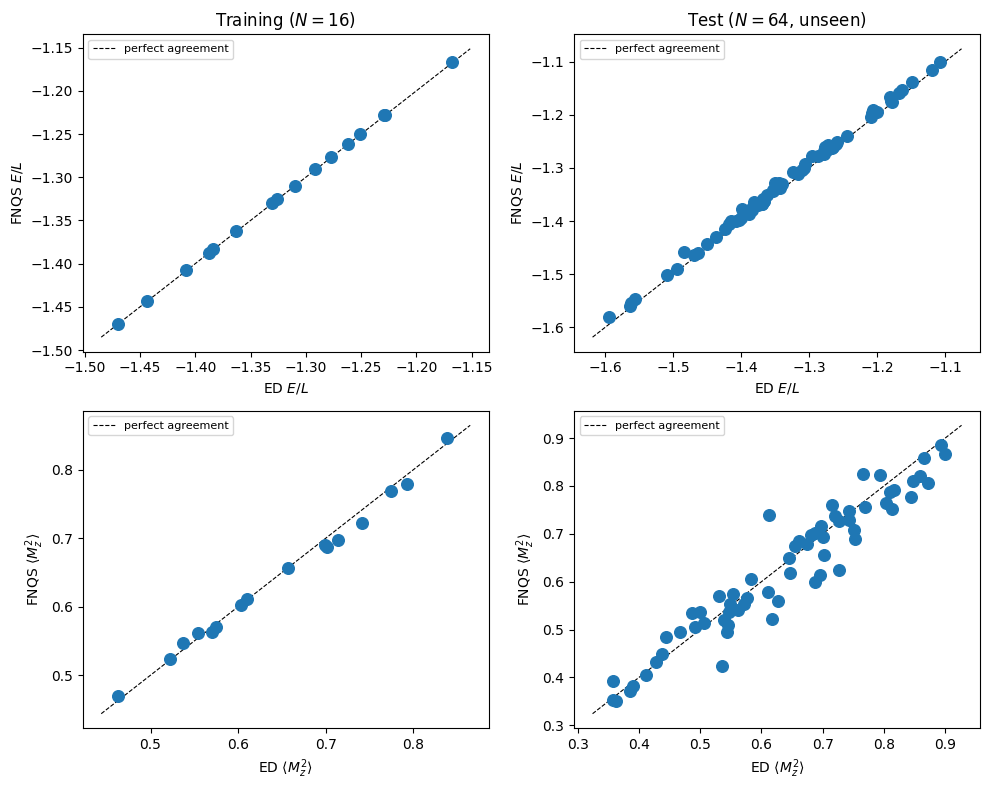

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

datasets = [
    (fnqs_train, ed_train,      fnqs_Mz2_train, ed_Mz2_train, f"Training ($N={n_train}$)"),
    (fnqs_test,  ed_test,       fnqs_Mz2_test,  ed_Mz2_test,  f"Test ($N={n_test}$, unseen)"),
]

for col, (fnqs_E, ed_E, fnqs_mz2, ed_mz2, title) in enumerate(datasets):
    for row, (fnqs_val, ed_val, ylabel) in enumerate([
        (fnqs_E / L, ed_E / L, "FNQS $E/L$"),
        (fnqs_mz2,   ed_mz2,   r"FNQS $\langle M_z^2 \rangle$"),
    ]):
        ax = axes[row, col]
        lo = min(ed_val.min(), fnqs_val.min())
        hi_ = max(ed_val.max(), fnqs_val.max())
        margin = 0.05 * (hi_ - lo)
        lim = [lo - margin, hi_ + margin]
        ax.plot(lim, lim, "k--", lw=0.8, label="perfect agreement")
        ax.scatter(ed_val, fnqs_val, s=70, zorder=5)
        if row == 0:
            ax.set_title(title)
        ax.set_xlabel("ED" + (" $E/L$" if row == 0 else r" $\langle M_z^2 \rangle$"))
        ax.set_ylabel(ylabel)
        ax.legend(fontsize=8)

plt.tight_layout()
plt.show()